NAMA : PRISCILLA TIARA S

Kelas : RE 6 A 

Nim : 4222301026

TUGAS IDENTIFIKASI KESUKSESAN MODEL DALAM MENTRAINING DATASET GARBAGE IMAGE DATASET

1. import tambahan buat training resnet, matplotlib buat plot grafik nanti, time buat ngitung lama training, pandas buat bikin tabel ringkasan: 

In [80]:
from torchvision import models
import matplotlib.pyplot as plt
import time
import pandas as pd

2. transfoem resnet 
ini transformasi gambar yg dipake khusus buat resnet. ukurannya harus 224x224 soalnya itu standar input resnet, terus ada normalize pake angka mean & std yg sesuai dataset imagenet (dataset yg dipake buat ngelatih resnet sebelumnya), biar gambar kita "match" sama yg model udah biasa liat

In [81]:
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [82]:
full_dataset_resnet = datasets.ImageFolder(data_dir, transform=transform_resnet)

print("kelas yang kedeteksi:", full_dataset_resnet.classes)
print("total gambar:", len(full_dataset_resnet))

num_classes = len(full_dataset_resnet.classes)

train_size = int(0.8 * len(full_dataset_resnet))
test_size = len(full_dataset_resnet) - train_size

train_dataset_resnet, test_dataset_resnet = random_split(
    full_dataset_resnet, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=32, shuffle=True)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=32, shuffle=False)

kelas yang kedeteksi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
total gambar: 2527


3. Model RESNET18 
ambil resnet18 yg udah dilatih sebelumnya pake jutaan gambar (pretrained). semua layer-nya di-freeze dulu (gk ikut dilatih), cuma layer paling akhir aja yg diganti & dilatih ulang biar sesuai jumlah kategori sampah kita (6 kelas)

In [83]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze semua layer dulu, biar yang dilatih cuma layer terakhir
for param in resnet_model.parameters():
    param.requires_grad = False

# ganti fully-connected terakhir sesuai jumlah kelas kita
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
resnet_model = resnet_model.to(device)

print(resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\LENOVO LOQ/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:11<00:00, 4.20MB/s]


Linear(in_features=512, out_features=6, bias=True)


4. fungsi training
fungsi training yg bakal dipake berulang. tiap epoch dia ngitung loss & akurasi di data latihan, terus ngetes juga ke data validasi yg blm pernah diliat modelnya. semua hasil per epoch disimpen ke "history" biar nanti bisa diplot

In [84]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    history = {"train_acc": [], "val_acc": [], "loss": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["loss"].append(running_loss/len(train_loader))

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    elapsed = time.time() - start_time
    print(f"\nTotal waktu training: {elapsed:.2f} detik")
    return history, elapsed

Training ResNet18

mulai training resnet18-nya, 10 epoch. yg dilatih cuma layer terakhir aja (sesuai yg di-setting sebelumnya), makanya prosesnya gk terlalu lama walau modelnya gede

In [85]:
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

print("=== TRAINING RESNET18 (PRETRAINED) ===")
history_resnet, time_resnet = train_model(
    resnet_model, train_loader_resnet, test_loader_resnet,
    criterion_resnet, optimizer_resnet, epochs=10
)

torch.save(resnet_model.state_dict(), "garbage_resnet18.pth")

=== TRAINING RESNET18 (PRETRAINED) ===
Epoch 1/10 | Loss: 1.3701 | Train Acc: 47.90% | Val Acc: 64.03%
Epoch 2/10 | Loss: 0.9586 | Train Acc: 68.09% | Val Acc: 71.34%
Epoch 3/10 | Loss: 0.8074 | Train Acc: 73.43% | Val Acc: 71.15%
Epoch 4/10 | Loss: 0.7271 | Train Acc: 76.25% | Val Acc: 75.30%
Epoch 5/10 | Loss: 0.6596 | Train Acc: 79.12% | Val Acc: 75.69%
Epoch 6/10 | Loss: 0.6204 | Train Acc: 79.56% | Val Acc: 73.52%
Epoch 7/10 | Loss: 0.5945 | Train Acc: 80.36% | Val Acc: 78.46%
Epoch 8/10 | Loss: 0.6226 | Train Acc: 79.56% | Val Acc: 75.30%
Epoch 9/10 | Loss: 0.5881 | Train Acc: 79.32% | Val Acc: 78.26%
Epoch 10/10 | Loss: 0.5321 | Train Acc: 82.19% | Val Acc: 77.27%

Total waktu training: 412.37 detik


PLOT GRAFIK visualisaasi

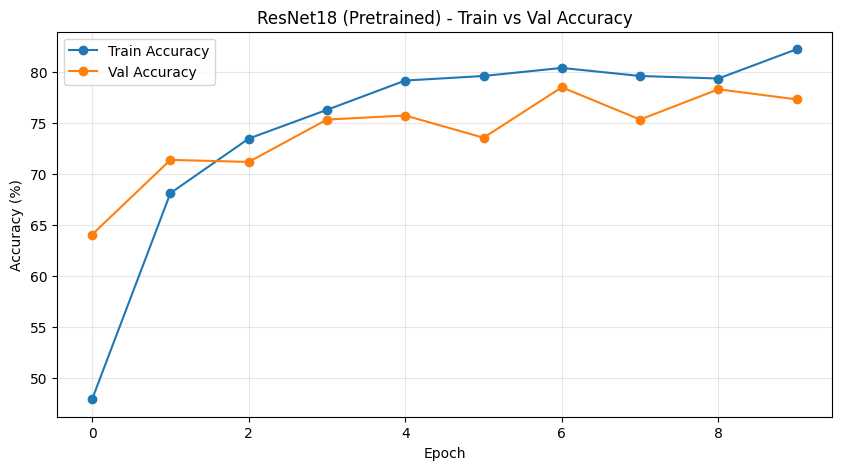

In [86]:
plt.figure(figsize=(10,5))
plt.plot(history_resnet["train_acc"], label="Train Accuracy", marker='o')
plt.plot(history_resnet["val_acc"], label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 (Pretrained) - Train vs Val Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
gap_resnet = history_resnet["train_acc"][-1] - history_resnet["val_acc"][-1]

summary = pd.DataFrame({
    "Model": ["ResNet18 (Pretrained)"],
    "Final Train Acc (%)": [history_resnet["train_acc"][-1]],
    "Final Val Acc (%)": [history_resnet["val_acc"][-1]],
    "Gap (Train-Val)": [gap_resnet],
    "Best Val Acc (%)": [max(history_resnet["val_acc"])],
    "Waktu Training (detik)": [time_resnet]
})

print(summary)

                   Model  Final Train Acc (%)  Final Val Acc (%)  \
0  ResNet18 (Pretrained)            82.187036          77.272727   

   Gap (Train-Val)  Best Val Acc (%)  Waktu Training (detik)  
0         4.914309         78.458498              412.367413  


KESIMPULAN : 
dari hasil training resnet18 selama 10 epoch, didapat:
- train acc akhir: 82.19%
- val acc akhir: 77.27%
- gap train-val: 4.91%
- best val acc: 78.46% (epoch ke-7)
- waktu training: ±412 detik (≈ 7 menit)

gap antara train acc dan val acc cuma sekitar 5%, ini termasuk gap yg kecil/wajar, jadi model resnet18 ini **gk menunjukkan overfitting yg signifikan**. beda jauh sama model cnn manual sebelumnya yg gap-nya lebih lebar.

ini wajar terjadi karna resnet18 itu model pretrained — dia udah "belajar" dari jutaan gambar imagenet sebelumnya, jadi pas dipake ke dataset sampah ini, dia gk perlu belajar dari nol & lebih cepet nemu pola yg general, gk gampang "ngapalin" data training doang.


karna gap train-val di model ini kecil (cuma 4.91%), itu nunjukin model resnet18 udah cukup seimbang antara belajar dari data latihan & generalisasi ke data baru, jadi syarat buat lanjut ke tahap perbaikan (kaya nambahin dropout, augmentasi, dll) gk terpenuhi. teknik² anti-overfitting itu dipake kalau emang ada bukti overfitting-nya jelas, kalau dipaksain dipake padahal modelnya udah sehat, malah bisa bikin model jadi underfitting (susah belajar) atau cuma buang² waktu training tanpa hasil yg signifikan beda.

jadi kesimpulannya, akurasi val acc terbaik (78.46%) ini sudah bisa dianggap hasil akhir yg representatif buat model resnet18 di kasus ini, gk perlu ada training tambahan lagi.

terimakasihh <3